## Data Load 

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv(r'C:\Users\JASON ALIFIAN S\Documents\Attack_Dataset.csv')
df.columns = df.columns.str.strip()

# Bikin 3 kolom numerik
df['desc_len'] = df['Scenario Description'].str.len()
df['steps_len'] = df['Attack Steps'].str.len()
df['tools_count'] = df['Tools Used'].str.count(',') + 1

print("Shape:", df.shape)
df[['desc_len', 'steps_len', 'tools_count']].head()

Shape: (14133, 19)


,desc_len,steps_len,tools_count
0,117,658,3.0
1,219,784,4.0
2,220,896,4.0
3,245,1274,5.0
4,304,1162,5.0


## Statistik Deskriptif Numerik 

In [30]:
num_cols = ['desc_len', 'steps_len', 'tools_count']

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Modus': df[num_cols].mode().iloc[0],
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Range': df[num_cols].max() - df[num_cols].min(),
    'Varians': df[num_cols].var(),
    'Std': df[num_cols].std(),
    'Q1': df[num_cols].quantile(0.25),
    'Q3': df[num_cols].quantile(0.75),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
}).round(2)

summary

,Mean,Median,Modus,Min,Max,Range,Varians,Std,Q1,Q3,IQR
desc_len,127.57,103.0,84.0,30.0,795.0,765.0,8268.96,90.93,79.0,143.0,64.0
steps_len,698.13,554.0,399.0,23.0,6003.0,5980.0,215959.70,464.71,387.0,890.0,503.0
tools_count,2.94,3.0,3.0,1.0,22.0,21.0,1.57,1.25,2.0,3.0,1.0


### Interpretasi 
`desc_len` (panjang deskripsi):
Rata-rata panjang deskripsi adalah 127,57 karakter, sedangkan nilai tengahnya (median) 103 karakter. Karena rata-rata lebih besar dari median, berarti ada beberapa deskripsi yang jauh lebih panjang sehingga menarik rata-ratanya ke atas. Sebagian besar deskripsi berada di sekitar 79–143 karakter (Q1–Q3).

`steps_len` (panjang langkah serangan):
Rata-ratanya 698,13 karakter, sedangkan mediannya hanya 554 karakter. Perbedaan ini cukup besar, menunjukkan ada beberapa langkah serangan yang sangat panjang dibandingkan yang lainnya. Jadi, data steps_len memiliki variasi yang cukup besar (simpangan baku 464,71).

`tools_count` (jumlah tools yang digunakan):
Rata-ratanya sekitar 2,94 tools, dengan median dan modus sama-sama 3 tools. Artinya, sebagian besar serangan menggunakan sekitar 3 tools. Nilainya juga tidak terlalu menyebar (IQR = 1), sehingga jumlah tools yang digunakan cenderung lebih stabil dibandingkan dua variabel lainnya.

## Hitung varians manual

In [31]:
x = df['desc_len'].head(10)
n = len(x)
xbar = x.mean()

manual_var = ((x - xbar) ** 2).sum() / (n - 1)
manual_std = manual_var ** 0.5

print(f"Manual varians : {manual_var:.2f}")
print(f"Pandas varians : {x.var():.2f}")
print(f"Selisih        : {abs(manual_var - x.var()):.6f}")

Manual varians : 4640.22
Pandas varians : 4640.22
Selisih        : 0.000000


**Interpretasi:** Hasil perhitungan varians manual dengan rumus s² = Σ(xᵢ − x̄)² / (n − 1) menggunakan 10 baris pertama menghasilkan nilai yang sama (selisih ≈ 0) dengan hasil pandas var(). Ini membuktikan bahwa pandas menggunakan pembagi n − 1 (sampel), bukan n (populasi).

## Ringkasan Variabel Kategorik

In [32]:
# Hitung frekuensi & persentase
freq = df['Category'].value_counts()
pct = (df['Category'].value_counts(normalize=True) * 100).round(2)

# Gabung jadi tabel
tabel = pd.DataFrame({
    'Frekuensi': freq,
    'Persentase (%)': pct
})

print(f"Jumlah kategori unik: {df['Category'].nunique()}")
print(f"\nModus (paling sering): {df['Category'].mode()[0]} — {freq.max()} serangan")

print("\n=== 10 Kategori Terbanyak ===")
print(tabel.head(10))

print("\n=== 10 Kategori Paling Sedikit ===")
print(tabel.tail(10))

Jumlah kategori unik: 64

Modus (paling sering): Insider Threat — 569 serangan

=== 10 Kategori Terbanyak ===
                                             Frekuensi  Persentase (%)
Category                                                              
Insider Threat                                     569            4.03
Physical / Hardware Attacks                        548            3.88
Quantum Cryptography & Post-Quantum Threats        542            3.83
Wireless Attacks (Advanced)                        535            3.79
Malware & Threat                                   528            3.74
Satellite & Space Infrastructure Security          515            3.64
DFIR                                               510            3.61
Blockchain / Web3                                  503            3.56
Red Team                                           503            3.56
Blue Team                                          503            3.56

=== 10 Kategori Paling Sedikit ===
  

Pada kolom `Category`, terdapat **64 jenis kategori serangan**. Kategori yang paling sering muncul (modus) adalah **Insider Threat**, yaitu sebanyak **569 serangan** atau **4,03%** dari seluruh data.

Lima kategori yang paling sering muncul adalah:

Insider Threat (569)
Physical / Hardware Attacks (548)
Quantum Cryptography & Post-Quantum Threats (542)
Wireless Attacks Advanced (535)
Malware & Threat (528)
Jumlah masing-masing kategori tersebut **tidak jauh berbeda**, yaitu berkisar **3,7%–4%**.

## Histogram desc_len

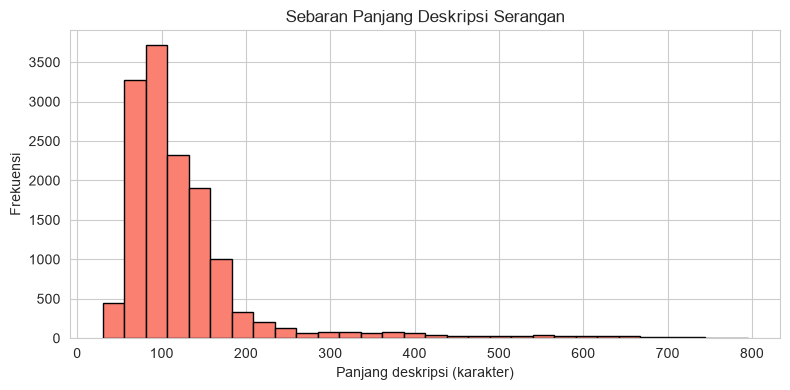

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(df['desc_len'], bins=30, color='salmon', edgecolor='black')
plt.title('Sebaran Panjang Deskripsi Serangan')
plt.xlabel('Panjang deskripsi (karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `desc_len` menunjukkan sebaran yang **miring ke kanan** (right-skewed). Mayoritas deskripsi serangan panjangnya berada di kisaran **50–150 karakter**, dengan puncak frekuensi tertinggi di sekitar **80–100 karakter**.

Namun, ada **ekor panjang ke kanan** yang mencapai **795 karakter**. Ini menandakan bahwa sebagian kecil serangan memiliki deskripsi yang jauh lebih detail dan panjang dibandingkan mayoritas.

## Histogram steps_len

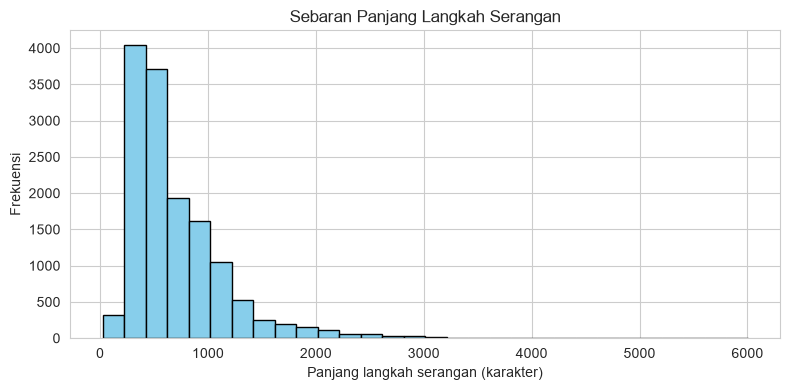

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(df['steps_len'], bins=30, color='skyblue', edgecolor='black')
plt.title('Sebaran Panjang Langkah Serangan')
plt.xlabel('Panjang langkah serangan (karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `steps_len` menunjukkan sebaran panjang langkah-langkah serangan. Sebagian besar langkah serangan memiliki panjang sekitar **200–800 karakter**.

Namun, ada beberapa serangan yang langkahnya jauh lebih panjang, bahkan mencapai **6.003 karakter**. Hal ini membuat grafik terlihat **memanjang ke arah kanan** (right-skewed).

## Histogram tools_count

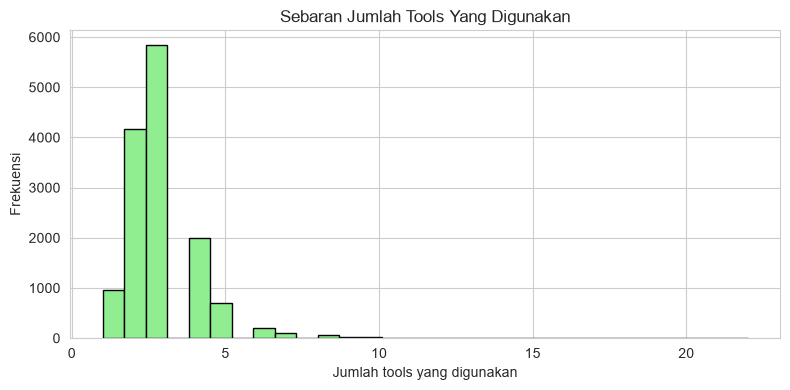

In [35]:
plt.figure(figsize=(8, 4))
plt.hist(df['tools_count'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Sebaran Jumlah Tools Yang Digunakan')
plt.xlabel('Jumlah tools yang digunakan')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Histogram `tools_count` menunjukkan sebaran jumlah tools yang digunakan. Mayoritas tiap serangan memakai **2-3 tools** yang mengisyaratkan sebagian besar attack scenario di sini adalah kasus umum dan frekuensi paling banyak dalam penggunaan tools ada di angka **3** sejumlah **5.840**. 

Histogram ini **condong ke kanan** (right-skewed), mayoritas data **menumpuk di sisi kiri** (jumlah tools kecil), lalu **ekornya memanjang tipis ke kanan** dengan sangat sedikit data di jumlah tools yang besar.